In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# sklearn stuff
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# math stuff
from scipy.stats import skew, kurtosis
from scipy.signal import hilbert
from math import log10

# Audio related
import librosa
import parselmouth
from maad import sound as suono
from maad import features as ft
from spafe.features.lfcc import lfcc

In [2]:
csvTotale = pd.read_csv('.././data/development.csv', header=0, index_col=0).drop(columns=['sampling_rate'])
csvTotale['gender'] = csvTotale['gender'].map(lambda x: 0 if x=='male' else 1)
csvTotale['tempo'] = csvTotale['tempo'].map(lambda x: float(x[1:-1]))
csvTotale['path'] = csvTotale['path'].map(lambda x: x.split('/')[-1])

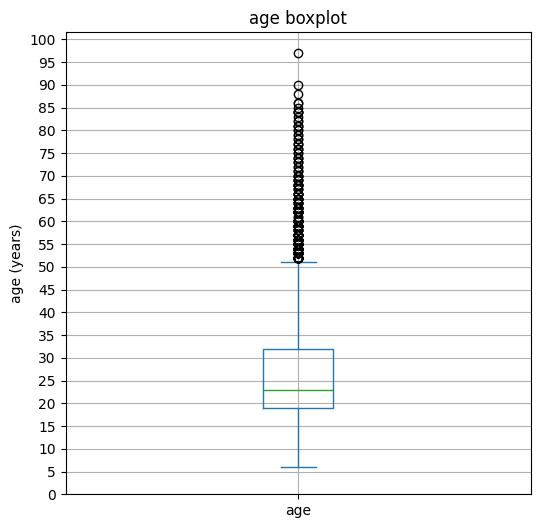

In [3]:
plt.figure(figsize=(6, 6))
csvTotale['age'].plot(kind='box')
plt.title('age boxplot')
plt.ylabel('age (years)')
plt.yticks(np.arange(0, 101, 5))
plt.grid()
plt.savefig('age_boxplot.svg')
plt.show()

In [4]:
csvTotale['gender'].value_counts()

gender
1    1468
0    1465
Name: count, dtype: int64

In [5]:
(csvTotale['ethnicity'].value_counts()/csvTotale.shape[0]*100).map(lambda x: round(x, 1))

ethnicity
igbo        36.9
english     19.7
arabic       3.5
mandarin     2.2
french       2.1
            ... 
hakka        0.0
malagasy     0.0
lingala      0.0
fang         0.0
rundi        0.0
Name: count, Length: 165, dtype: float64

In [6]:
csvEval = pd.read_csv('.././data/evaluation.csv', header=0, index_col=0).drop(columns=['sampling_rate'])
csvEval['gender'] = csvEval['gender'].map(lambda x: 0 if x=='male' else 1)
csvEval['tempo'] = csvEval['tempo'].map(lambda x: float(x[1:-1]))
csvEval['path'] = csvEval['path'].map(lambda x: x.split('/')[-1])

In [7]:
csvEval['gender'].value_counts()

gender
0    393
1    298
Name: count, dtype: int64

In [8]:
(csvEval['ethnicity'].value_counts()/csvEval.shape[0]*100).map(lambda x: round(x, 1))
csvEval[csvEval['ethnicity']=='american'].count()

gender                    0
ethnicity                 0
mean_pitch                0
max_pitch                 0
min_pitch                 0
jitter                    0
shimmer                   0
energy                    0
zcr_mean                  0
spectral_centroid_mean    0
tempo                     0
hnr                       0
num_words                 0
num_characters            0
num_pauses                0
silence_duration          0
path                      0
dtype: int64

In [9]:
cross_val_score(HistGradientBoostingRegressor(categorical_features=csvTotale.drop(columns=['path', 'age']).dtypes == 'object'), 
                csvTotale.drop(columns=['path', 'age']), 
                csvTotale['age'], cv=15, scoring='neg_root_mean_squared_error').mean(),

(np.float64(-10.45807864893618),)

In [10]:
audioDevelopment = {file: librosa.load('.././data/audios_development/'+file, sr=22050)[0] for file in csvTotale['path']}

In [11]:
def getMFCC(audio):
    numFcc = 35
    return pd.Series(librosa.feature.mfcc(y=audio, sr=22050, n_mfcc=numFcc).mean(axis=1), 
                     index=[f'mfcc{i}' for i in range(numFcc)])

In [12]:
def getSpectralEnergy(audio):
    S = librosa.stft(audio)
    freqs = librosa.fft_frequencies(sr=22050)
    return pd.Series([np.sum(np.abs(S[(freqs >= 250) & (freqs <= 650)])**2), np.sum(np.abs(S[(freqs >= 1000) & (freqs <= 8000)])**2)],
                        index=['spectralEnergy250-650', 'spectralEnergy1000-8000'])

In [13]:
def computeF0(audio):
    sound = parselmouth.Sound(audio)
    pitch = sound.to_pitch()
    info = str(pitch.info()).split('\n')
    return pd.Series([pitch.count_voiced_frames(), pitch.get_mean_absolute_slope(), pitch.xmax-pitch.xmin, 
                      pitch.n_frames, *[float(info[15+i].split('=')[2].lstrip().split(' =')[0].split()[0]) for i in range(0, 5)],
                      *[float(info[21+i].split('=')[2].lstrip().split(' =')[0].split()[0]) for i in range(0, 3)]],
                     index=['nVoicedFrames', 'meanAbsoluteSlope', 'duration', 'nFrames', 
                            'q10', 'q16', 'q50', 'q84', 'q90', '84-median', 'median-16', '90-10']
                     )

In [14]:
def computeMath(audio):
    return pd.Series([skew(audio), kurtosis(audio), np.mean(np.abs(hilbert(audio))), np.mean(np.abs(np.fft.fft(audio)))],
                     index=['skew', 'kurtosis', 'hilbertMean', 'fftMean'])

In [15]:
def computSNR(audio):
    return pd.Series([suono.temporal_snr(audio)[-1]], index=['temporalSNR'])

In [16]:
def computeTemporalMedia(audio):
    return pd.Series([ft.temporal_median(audio)], index=['temporalMedian'])

In [17]:
def computeAllFeatures(audio):
    return pd.Series(ft.all_temporal_features(audio, fs=22050, nperseg=256).values[0],
                     index=['sm', 'sv', 'ss', 'sk', 'Time 5%', "Time 25%", "Time 50%", "Time 75%", "Time 95%", 
                            "zcr", "duration_5", "duration_90"])

In [18]:
# controlla che la durata_5 e durata_90 siano corrette e diverse dai quantili
# e che lo zcr sia uguale a quello già dato

In [19]:
def computePeakFrequency(audio):
    return pd.Series(ft.peak_frequency(audio, fs=22050, nperseg=256, amp=True), index=['peakFrequency', 'peakFrequencyAmp'])

In [20]:
def computeEntropy(audio):
    return pd.Series(ft.temporal_entropy(audio), index=['entropy'])

In [21]:
def getOnsetRate(audio):
    return pd.Series(librosa.onset.onset_detect(y=audio, sr=22050, hop_length=512).shape[0]/audio.shape[0], index=['onsetRate'])

In [22]:
# FUCKING GOATED
def getPausesAndArticulationRate(audio):
    intervals = librosa.effects.split(audio, top_db=20)
    total_duration = len(audio) / 22050
    speech_duration = sum((end - start) for start, end in intervals) / 22050
    return pd.Series([total_duration - speech_duration, speech_duration / total_duration], index=['pauses', 'articulation_rate'])

In [23]:
def getLFCC(audio):
    return pd.Series(lfcc(audio, fs=22050, num_ceps=15, low_freq=50, high_freq=3000, nfft=256).mean(axis=0),
                        index=[f'lfcc{i}' for i in range(15)])

In [24]:
def getPitchStats(audio):
    _, flag, prob = librosa.pyin(y=audio, fmin=50, fmax=2000, sr=22050)
    return pd.Series([flag[flag].shape[0], np.mean(prob), np.std(prob)], index=['FrameVoice', 'meanProb', 'stdProb'])

In [25]:
def pitchStats2File(diz, path):
    try:
        data = pd.read_csv(path, header=0, index_col=0).index
    except Exception:
        data = set()
        
    with open(path, 'a+', encoding='utf-8') as fp:
        for file in set(diz.keys()).difference(data):
            fp.write(file + ',' + ','.join(map(str, getPitchStats(diz[file]))) + '\n')

# DA PROVARE

In [26]:
def getAdvancedHilbert(audio):
    hilb = np.abs(hilbert(audio))
    return pd.Series([np.mean(hilb), np.std(hilb), np.median(hilb), np.percentile(hilb, 25), np.percentile(hilb, 75), skew(hilb), kurtosis(hilb)],
                     index=['hilbertMean', 'hilbertStd', 'hilbertMedian', 'hilbert25', 'hilbert75', 'hilbertSkew', 'hilbertKurtosis'])

# add the code for the wavelet transform

In [27]:
def computeMetrics(audios):
    return pd.DataFrame({file: pd.concat([
            getMFCC(audios[file]),
            getSpectralEnergy(audios[file]),
            computeF0(audios[file]),
            computeMath(audios[file]),
            computSNR(audios[file]),
            computeTemporalMedia(audios[file]),
            computeAllFeatures(audios[file]),
            computePeakFrequency(audios[file]),
            computeEntropy(audios[file]),   # fucking entropy drops the score
            # only the upper one for 9100
            getPausesAndArticulationRate(audios[file]),
            getOnsetRate(audios[file]),
            getLFCC(audios[file])
            ], axis=0)
        for file in audios}).T

In [28]:
metrics = pd.concat([computeMetrics(audioDevelopment), 
                    csvTotale.set_index('path')[['hnr', 'shimmer', 'jitter', 'gender', 'max_pitch', 'mean_pitch', 'min_pitch']]], axis=1)

metrics['hnr']= metrics['hnr'].map(lambda x: 10*log10(np.abs(x)))

In [29]:
csvTotale.ethnicity.unique()

array(['arabic', 'hungarian', 'portuguese', 'english', 'dutch', 'italian',
       'french', 'igbo', 'hebrew', 'farsi', 'german', 'nama', 'belarusan',
       'urhobo', 'polish', 'croatian', 'kikuyu', 'icelandic', 'bengali',
       'maltese', 'finnish', 'armenian', 'hindi', 'bosnian', 'miskito',
       'azerbaijani', 'kiswahili', 'mongolian', 'russian', 'malay',
       'bulgarian', 'gan', 'cantonese', 'punjabi', 'nigerian', 'mandarin',
       'oriya', 'igala', 'japanese', 'ga', 'ibibio', 'korean', 'amharic',
       'gujarati', 'norwegian', 'kurdish', 'congolese', 'marathi', 'ijaw',
       'nepali', 'indonesian', 'yoruba', 'bari', 'kanuri', 'pashto',
       'romanian', 'albanian', 'georgian', 'baga', 'macedonian', 'danish',
       'khmer', 'catalan', 'papiamentu', 'naxi', 'czech', 'mizo', 'irish',
       'agni', 'hausa', 'estonian', 'ika', 'bafang', 'quechua',
       'lithuanian', 'afemai', 'ikwerre', 'luxembourgeois', 'moore',
       'kabyle', 'fijian', 'greek', 'mankanya', "sa'a", 'bai'

In [30]:
(lambda models, cv :  [print(model, '-->', -cross_val_score(make_pipeline(StandardScaler(), model), metrics,
                 csvTotale['age'], cv=cv, scoring='neg_root_mean_squared_error').mean()) for model in models]
)([HistGradientBoostingRegressor(), RandomForestRegressor(n_jobs=-1), SVR()], 15);

HistGradientBoostingRegressor() --> 9.787135301464224
RandomForestRegressor(n_jobs=-1) --> 10.121254999832903
SVR() --> 10.937050755731098


In [31]:
for item, imp in sorted(zip(list(metrics.columns)+['age'], 
                            pd.concat([metrics, csvTotale.set_index(csvTotale['path'])['age']], axis=1).corr('spearman')['age']), key=lambda x: abs(x[1]), reverse=True):
    print(f'{item}: {imp}')

age: 1.0
nFrames: 0.6022603562876916
duration: 0.602252908183809
Time 95%: 0.6016573045219915
duration_90: 0.5994765605409939
duration_5: 0.5948130345006974
pauses: 0.5911350873258561
Time 75%: 0.5904688371671031
Time 50%: 0.5818011133930301
nVoicedFrames: 0.5644983266317832
Time 25%: 0.5518922891861292
Time 5%: 0.5350617896196377
hnr: 0.5320784492500874
spectralEnergy250-650: 0.5303528487661241
articulation_rate: -0.519070326215834
sm: 0.5010898324353773
fftMean: 0.49037696789958823
spectralEnergy1000-8000: 0.4742084761261652
max_pitch: 0.4694639426920942
min_pitch: -0.46452284591811516
temporalSNR: 0.4389244252671011
mfcc6: -0.4222780140021344
ss: -0.41707174962926924
skew: -0.4170666241622713
lfcc5: -0.4101359458244979
mean_pitch: 0.36619218880953386
zcr: 0.3610859442341537
lfcc2: -0.3591440886252686
jitter: 0.34920179676737306
mfcc13: -0.34195572156396453
mfcc33: -0.32793932338185033
kurtosis: 0.32287861765139875
sk: 0.3228641469774155
mfcc15: -0.3187933132261265
mfcc17: -0.3168372

In [32]:
# jitter in db
# metrics['jitter'] = metrics['jitter'].map(lambda x: 20*log10(x))

pyinDev, pyinDevEval, metricsOriginal, metricsEvalOriginal

In [33]:
audioEval = {file: librosa.load('.././data/audios_evaluation/'+file, sr=22050)[0] for file in csvEval['path']}

In [34]:
metricsEval = pd.concat([computeMetrics(audioEval), 
                    csvEval.set_index('path')[['hnr', 'shimmer', 'jitter', 'gender', 'max_pitch', 'mean_pitch', 'min_pitch']]], axis=1)
metricsEval['hnr']= metricsEval['hnr'].map(lambda x: 10*log10(np.abs(x)))

In [37]:
pd.Series(HistGradientBoostingRegressor(warm_start=True)
          .fit(metrics, csvTotale['age'])
          .predict(metricsEval),
          name='Predicted').to_csv('Final-Baseline.csv', header=True, index_label='Id')

In [56]:
from sklearn.model_selection import ParameterGrid


lines = {','.join(line.split(',')[:-1]) for line in open('hyper.csv', 'r', encoding='utf-8')}

with open('hyper.csv', 'a+', encoding='utf-8') as fp:
    orderedParam = sorted({'loss', 'max_iter','max_depth', 'learning_rate','l2_regularization','min_samples_leaf','quantile'})
    fp.write(','.join(orderedParam + ['score']) + '\n')
    
    for params in ParameterGrid({
        'loss': ['quantile', 'absolute_error', 'poisson', 'squared_error'],
        'max_iter': [100, 200, 300, 400, 500, 1000],
        'max_depth': [None, 15, 20, 25, 35, 40, 50],
        'learning_rate': [0.3, 0.1, 0.01, 0.001],
        'min_samples_leaf': [10, 20, 30, 40, 50],
        'quantile':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    }):
        if ','.join(map(str, [params[key] for key in orderedParam])) not in lines:
            score = cross_val_score(HistGradientBoostingRegressor(**params), metrics,
                    csvTotale['age'], cv=20, scoring='neg_root_mean_squared_error').mean()
            fp.write(','.join(map(str, [params[key] for key in orderedParam] + [score])) + '\n')

KeyboardInterrupt: 

In [41]:
hyper = pd.read_csv('hyper.csv', header=0)

hyper.sort_values('score', ascending=False).head(10)

,l2_regularization,learning_rate,loss,max_depth,max_iter,min_samples_leaf,quantile,score
671,0,0.3,quantile,15,300,50,0.6,-10.060793
536,0,0.3,quantile,15,300,50,0.6,-10.066118
311,0,0.3,quantile,15,200,50,0.6,-10.070307
86,0,0.3,quantile,15,100,50,0.6,-10.074943
446,0,0.3,quantile,15,200,50,0.6,-10.084929
626,0,0.3,quantile,15,300,50,0.6,-10.094210
221,0,0.3,quantile,15,100,50,0.6,-10.095520
464,0,0.3,quantile,15,300,20,0.6,-10.100787
401,0,0.3,quantile,15,200,50,0.6,-10.103437
239,0,0.3,quantile,15,200,20,0.6,-10.103789


In [34]:
pd.Series(HistGradientBoostingRegressor().fit(metricsOriginal, csvTotale['age'])
          .predict(metricsEvalOriginal),
          name='Predicted',
          index=csvEval.index).to_csv('Porca.csv')

NameError: name 'metricsOriginal' is not defined

In [ ]:
pd.Series(np.zeros(csvEval.shape[0])+
          (csvTotale['age'].mean()+csvTotale['age'].median())/2,  
          name='Predicted').to_csv('Naive-Baseline.csv', header=True, index_label='Id')

In [ ]:
from sklearn.model_selection import ParameterGrid
lista = list(
    map(lambda x: [x, -cross_val_score(DecisionTreeRegressor(**x), metrics, csvTotale['age'], 
                                       cv=15, scoring='neg_root_mean_squared_error').mean()],
        ParameterGrid({
            'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
            'splitter': ['best', 'random'],
            'max_features': ['sqrt', 'log2'],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_depth': [10, 20, 30, None]
        })
))

In [ ]:
pd.Series(DecisionTreeRegressor(**(sorted(lista, key=lambda x: x[1])[0][0]))
          .fit(metrics, csvTotale['age'])
          .predict(metricsEval),
          name='Predicted').to_csv('Tree-Baseline.csv', header=True, index_label='Id')

In [ ]:
tempScaler = StandardScaler()

pd.Series((SVR().fit(tempScaler.fit_transform(metrics), csvTotale['age']).predict(tempScaler.transform(metricsEval)) +
          RandomForestRegressor(n_jobs=-1).fit(metrics, csvTotale['age']).predict(metricsEval))/2,
            name='Predicted').to_csv('Ensemble.csv', header=True, index_label='Id')

In [55]:
-(cross_val_score(make_pipeline(StandardScaler(), SVR()), metrics, csvTotale['age'], cv=15, scoring='neg_root_mean_squared_error').mean()+
cross_val_score(RandomForestRegressor(n_jobs=-1), metrics, csvTotale['age'], cv=15, scoring='neg_root_mean_squared_error').mean())/2

np.float64(10.514802025127041)